Evaluando el modelo contra el dataset completo...

--- REPORTE DE CLASIFICACIÓN ---
                   precision    recall  f1-score   support

data_exfiltration       1.00      1.00      1.00      1153
        jailbreak       0.99      1.00      1.00      1153
      obfuscation       0.98      1.00      0.99      1153
 prompt_injection       1.00      1.00      1.00      1153
             safe       1.00      0.97      0.98      1153

         accuracy                           0.99      5765
        macro avg       0.99      0.99      0.99      5765
     weighted avg       0.99      0.99      0.99      5765



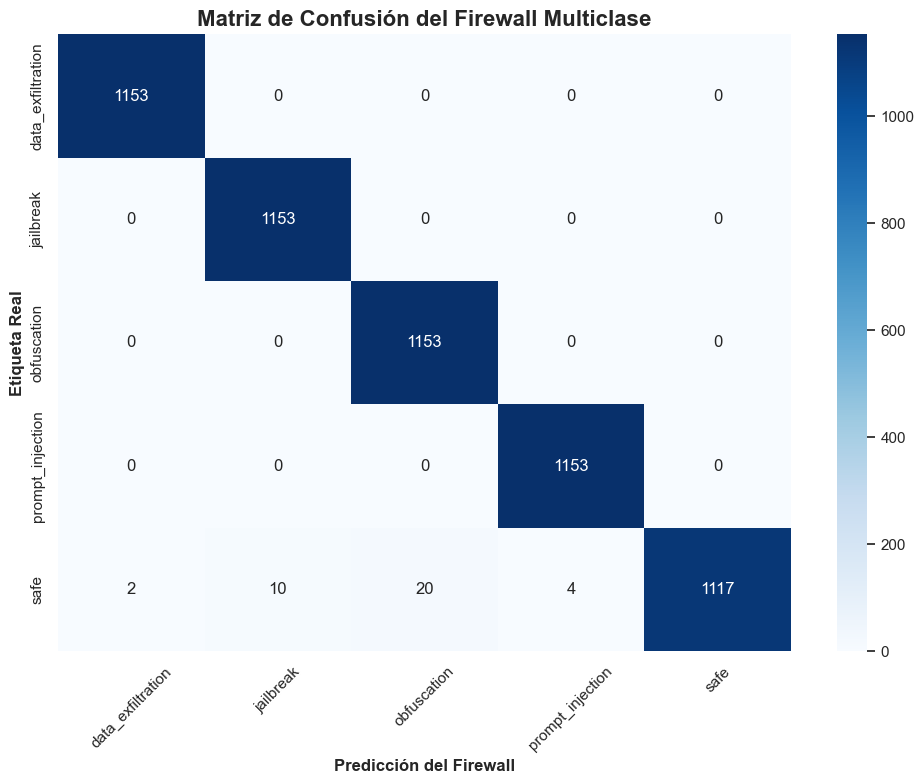

In [2]:
import sys
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from firewall import analyze_prompt

sns.set_theme(style="white")
df = pd.read_csv("../dataset/prompts_multiclass.csv")

y_true = []
y_pred = []

print("Evaluando el modelo contra el dataset completo...")
for prompt, true_category in zip(df["prompt"], df["category"]):
    
    score, decision, attack_type = analyze_prompt(prompt)
    
    y_true.append(true_category)
    y_pred.append(attack_type)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred))

labels = sorted(df["category"].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

plt.title("Matriz de Confusión del Firewall Multiclase", fontsize=16, fontweight="bold")
plt.xlabel("Predicción del Firewall", fontsize=12, fontweight="bold")
plt.ylabel("Etiqueta Real", fontsize=12, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()